<a href="https://colab.research.google.com/github/crypt0d1v3r/CannyValley/blob/JakeTest/TrainHewgModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies for pulling datasets
%pip install kagglehub
%pip install datasets
%pip install torch
%pip install torchvision
%pip install numpy
%pip install matplotlib

In [ ]:
import kagglehub
from datasets import load_dataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch
import os
import numpy as np
import matplotlib.pyplot as plt

class CNN(torch.nn.Module):
  def __init__(self):
      super().__init__()
      self.model = torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3, out_channels=32,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=32, out_channels=64,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=64, out_channels=64,
                          kernel_size=3, padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Flatten(),
          torch.nn.Linear(64 * 28 * 28, 512),
          torch.nn.ReLU(),
          torch.nn.Linear(512, 2)
      )

  def forward(self, x):
      return self.model(x)

In [ ]:
dataset_path = "./datasets"
dataset_source = "Hemg/AI-vs-Real-images"
if dataset_source == "birdy654/cifake-real-and-ai-generated-synthetic-images":
  dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
elif dataset_source == "Hemg/AI-vs-Real-images":
  dataset_path = load_dataset("Hemg/AI-vs-Real-images")
elif dataset_source == "bitmind/AI-vs-Real-Dataset-Images-Proper":
  dataset_path = load_dataset("bitmind/AI-vs-Real-Dataset-Images-Proper")
else:
  raise Exception(f"Dataset Source {dataset_source} Unknown")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/train-00000-of-00006-f19feedd0ed1ea(…):   0%|          | 0.00/91.2M [00:00<?, ?B/s]

data/train-00001-of-00006-95d0f15200cba9(…):   0%|          | 0.00/25.9M [00:00<?, ?B/s]

data/train-00002-of-00006-27c9ab02d7f950(…):   0%|          | 0.00/339M [00:00<?, ?B/s]

data/train-00003-of-00006-d009c6f04a3a8c(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00004-of-00006-a64ab7ba7a79c0(…):   0%|          | 0.00/40.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127260 [00:00<?, ? examples/s]

Can choose from the following datasets

---



*   birdy654/cifake-real-and-ai-generated-synthetic-images
*   Hemg/AI-vs-Real-images
*   bitmind/AI-vs-Real-Dataset-Images-Proper



In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, Subset, random_split # Import random_split
from torchvision import transforms, datasets
from PIL import Image # Add PIL import
from datasets import DatasetDict # Add DatasetDict import for type checking

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda image: image.convert('RGB')), # Explicitly convert to RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define a custom dataset class for Hugging Face datasets
class HFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'] # This is expected to be a PIL Image from Hugging Face datasets
        label = item['label']

        if self.transform:
            image = self.transform(image)
        return image, label

# Conditional data loading based on the type of dataset_path
if isinstance(dataset_path, DatasetDict):
    print("Loading dataset from Hugging Face DatasetDict and creating train/test split.")

    # Use the 'train' split as the full dataset since no 'test' or 'validation' split exists
    full_dataset = HFDataset(dataset_path['train'], transform=data_transforms)

    # Define split ratios (e.g., 80% train, 20% test)
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size

    # Split the dataset
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    if 'label' in dataset_path['train'].features and hasattr(dataset_path['train'].features['label'], 'names'):
        class_names = dataset_path['train'].features['label'].names
    else:
        # Default class names for 'Hemg/AI-vs-Real-images'
        class_names = ["Real", "AI"]
else:
    # This is a string path, assumed for ImageFolder
    print("Loading dataset from local image folders.")
    train_dir = os.path.join(dataset_path, 'train')
    test_dir = os.path.join(dataset_path , 'test')

    train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms)
    class_names = train_dataset.classes

#train_dataset = Subset(train_dataset, range(min(1000, len(train_dataset))))
#test_dataset = Subset(test_dataset, range(min(1000, len(test_dataset))))

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Get class names
# class_names already set in the conditional block above
print(f"Classes: {class_names}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
model = CNN().to(device)

Loading dataset from Hugging Face DatasetDict and creating train/test split.
Classes: ['Fake', 'Real']
Using device: cuda


In [ ]:
print(dataset_path)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 127260
    })
})


In [ ]:
print(dataset_path)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 127260
    })
})


In [ ]:
print(dataset_path)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 127260
    })
})


Epoch 1/20: 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Training loss = 0.2587743378592635
Epoch 2/20: Training loss = 0.25437693246584653
Epoch 3/20: Training loss = 0.25310649597194307
Epoch 4/20: Training loss = 0.2528714851238007
Epoch 5/20: Training loss = 0.25175435631053017
Epoch 6/20: Training loss = 0.25096999738999953
Epoch 7/20: Training loss = 0.2500697859696983
Epoch 8/20: Training loss = 0.2512863393097947
Epoch 9/20: Training loss = 0.24952988582824215
Epoch 10/20: Training loss = 0.24835215510342723
Epoch 11/20: Training loss = 0.2487057674872864
Epoch 12/20: Training loss = 0.24880605867796354
Epoch 13/20: Training loss = 0.2492513953527233
Epoch 14/20: Training loss = 0.24589093797854814
Epoch 15/20: Training loss = 0.24697241768601516
Epoch 16/20: Training loss = 0.24636687065335958
Epoch 17/20: Training loss = 0.24659021394965336
Epoch 18/20: Training loss = 0.24641887360679174
Epoch 19/20: Training loss = 0.24641032492136672
Epoch 20/20: Training loss = 0.24475731737888287


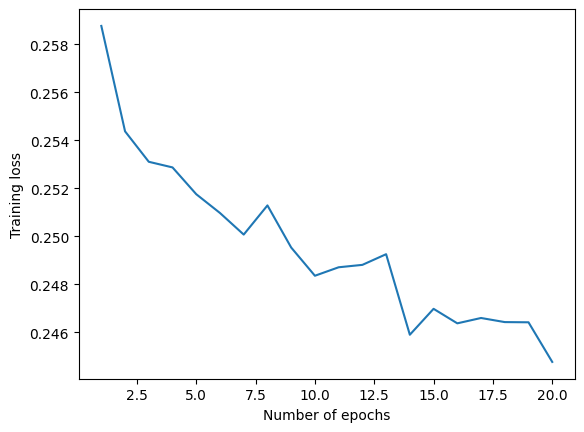

Test set accuracy = 91.19519094766619 %


NameError: name 'torchvision' is not defined

In [ ]:
num_epochs = 20
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_loss_list = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss_list.append(train_loss / len(train_loader))
    print(f"Training loss = {train_loss_list[-1]}")

plt.plot(range(1, num_epochs + 1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()

test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")



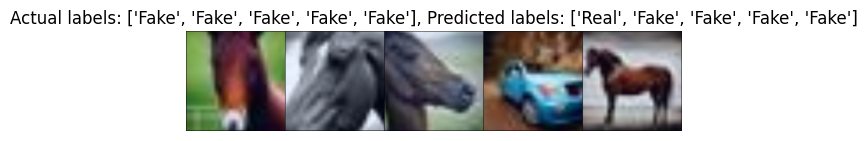

In [ ]:
import torchvision # Added import for torchvision

num_images = 5
y_true_name = [class_names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [class_names[y_pred[idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()

In [ ]:
# Save the trained model weights
torch.save(model.state_dict(), "cnn_model_Hemg.pth")
print("Model saved to cnn_model.pth")

# To load later:
# model = CNN().to(device)
# model.load_state_dict(torch.load("cnn_model.pth"))
# model.eval()

Model saved to cnn_model.pth


In [ ]:
from google.colab import files
files.download('cnn_model_Hemg.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>